### **Secant Method**

By      > Darshan Sherstha
Roll    > KCED081BCT010

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
def func(x):        # 0 and -1
    return x**5 + 7 * x**4 - 1

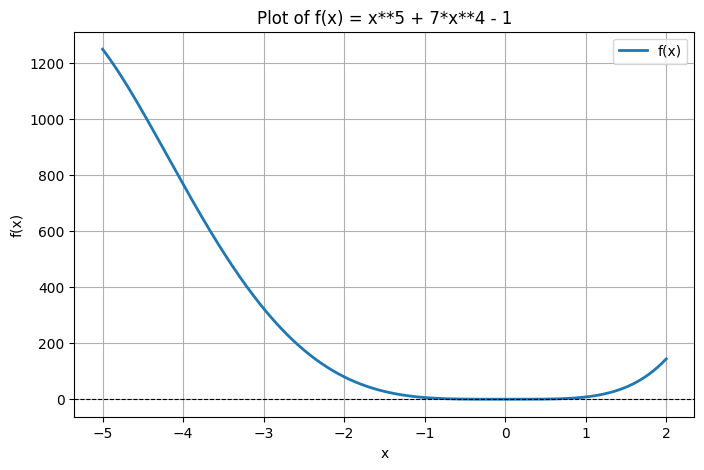

In [ ]:
# Simple plot of the function used by the Secant method
x = np.linspace(-5, 2, 400)
y = func(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='C0', linewidth=2, label='f(x)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x) = x**5 + 7*x**4 - 1')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
def get_input():
    print("f(x) = x**5 + 7 * x**4 - 1")

    try:
        while True:
            guesses = input("Enter initial guesses separated by space:\n> ").strip().split()

            if len(guesses) != 2:
                print("\n---> Print exaclty two numbers! <---")
                continue
            X0, X1 = map(float, guesses)

            if func(X0) * func(X1) >= 0:
                print("\n--> The product of funcitonal values of guesses should be strictly less than zero. <---\n")
            else:
                break
    except ValueError:
        print("\n---> Invalid numbers; try again. <---\n")
        
    return [X0, X1]

In [9]:
def use_secant(X0, X1):
    TOL = 10*-5
    iter_list = []
    x0_list = []
    x1_list = []
    x2_list = []

    func_x0_list = []
    func_x1_list = []
    func_x2_list = []

    for iteration in range(1, 101):

        func_X0 = func(X0)
        func_X1 = func(X1)

        if func_X0 == func_X1: continue

        iter_list.append(iteration)

        x0_list.append(X0)
        x1_list.append(X1)

        func_x0_list.append(X0)
        func_x1_list.append(X1)
        
        X2 = X1 - func_X1 * (X1-X0)/(func_X1 - func_X0)
        func_X2 = func(X2)
        
        x2_list.append(X2)
        func_x2_list.append(func_X2)

        if ( abs(func_X2) < TOL or abs(func_X2) == 0): break;

        X0 = X1
        X1 = X2

    return {"Iter." : iter_list, "X,i-1" : x0_list, "X,i" : x1_list, 
            "func(X,i-1)": func_x0_list, "func(X,i)" : func_x1_list,
            "X,i+1" : x2_list,"func(X,i+1)" : func_x2_list
            }

In [10]:
def display_table(table:dict): 
    df = pd.DataFrame(table)
    print(df.to_string(index=False))

    print(f"\n---> ROOT = {df['X,i+1'].iat[-1]:.6f}")

In [11]:
def main():
    X0, X1 = get_input()
    table = use_secant(X0, X1)
    display_table(table)
    
if __name__ == "__main__":
    main()

f(x) = x**5 + 7 * x**4 - 1
 Iter.     X,i-1       X,i  func(X,i-1)  func(X,i)     X,i+1   func(X,i+1)
     1  0.000000 -1.000000     0.000000  -1.000000 -0.166667 -9.947274e-01
     2 -1.000000 -0.166667    -1.000000  -0.166667 -0.304945 -9.421053e-01
     3 -0.166667 -0.304945    -0.166667  -0.304945 -2.780570  2.512255e+02
     4 -0.304945 -2.780570    -0.304945  -2.780570 -0.314194 -9.348456e-01
     5 -2.780570 -0.314194    -2.780570  -0.314194 -0.323337 -9.270234e-01
     6 -0.314194 -0.323337    -0.314194  -0.323337 -1.406982  2.091798e+01
     7 -0.323337 -1.406982    -0.323337  -1.406982 -0.369323 -8.766369e-01
     8 -1.406982 -0.369323    -1.406982  -0.369323 -0.411061 -8.118779e-01
     9 -0.369323 -0.411061    -0.369323  -0.411061 -0.934319  3.622318e+00
    10 -0.411061 -0.934319    -0.411061  -0.934319 -0.506867 -5.714229e-01
    11 -0.934319 -0.506867    -0.934319  -0.506867 -0.565110 -3.437463e-01
    12 -0.506867 -0.565110    -0.506867  -0.565110 -0.653045  1.543498e-0